# 06 · AIM policy diagnostics — Uni-Mol

Figure 2 of the AIM paper, **first two columns only**:

| | |
|---|---|
| **Threshold Matrix τ_ij** | what the policy learned — free, straight out of `history.json` |
| **Conflict Rate** | fraction of batches with **cos φ_ij < τ_ij** — the paper's definition, conflict measured *against the learned threshold*, not against zero |

Note the second panel needs measured cosines, so it exists only at the
checkpoint that `10_measure_gradients.ipynb` was run on. τ is free at every
epoch, so the τ row can show as many epochs as you like.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
import common as C
C.apply_style()

BACKBONE = "Uni-Mol"
TAG      = "11task"        # "2task" or "11task"
METHOD   = "aim_matrix"    # only AIM runs carry tau
K        = 10.0            # gate temperature, must match training
ANNOTATE = False           # print the value in every cell
EPOCHS   = None            # e.g. [10, 100] for extra tau-only rows; None = checkpoint only

## Load τ (free) and the measured cosines (from the cache)

In [2]:
trace = C.load_tau_trace(BACKBONE, TAG, METHOD)
assert trace is not None, f"no tau logged for {BACKBONE} {TAG} {METHOD}"
ck_epoch = trace["best"]["epoch"]
tasks = C.load_runs(BACKBONE, TAG)["tasks"]
print(f"{BACKBONE} {TAG} {METHOD}: {len(trace['epoch'])} epochs, checkpoint at epoch {ck_epoch}")

cache = C.load_cache(TAG, METHOD)          # raises with instructions if missing
entry = cache[BACKBONE]
cos   = entry["cos"]                       # [batches, n, n]
tau_ck = entry["tau"]                      # tau from that same checkpoint
print(f"cosines: {cos.shape[0]} batches x {cos.shape[1]}x{cos.shape[2]}")

# The paper's definition: conflict when cos phi_ij < tau_ij.
conflict_rate = (cos < tau_ck[None]).mean(axis=0)
# For contrast, the sign-based definition used elsewhere in this project:
conflict_zero = (cos < 0).mean(axis=0)
off = ~np.eye(len(tasks), dtype=bool)
print(f"conflict rate (cos < tau) mean off-diag : {conflict_rate[off].mean():.3f}")
print(f"conflict rate (cos < 0)   mean off-diag : {conflict_zero[off].mean():.3f}")

Uni-Mol 11task aim_matrix: 400 epochs, checkpoint at epoch 384
cosines: 16 batches x 11x11
conflict rate (cos < tau) mean off-diag : 0.266
conflict rate (cos < 0)   mean off-diag : 0.353


## The figure

saved E:\Projects\aim_mtl\notebooks\figures\11task\policy_diagnostics_UniMol_11task.png


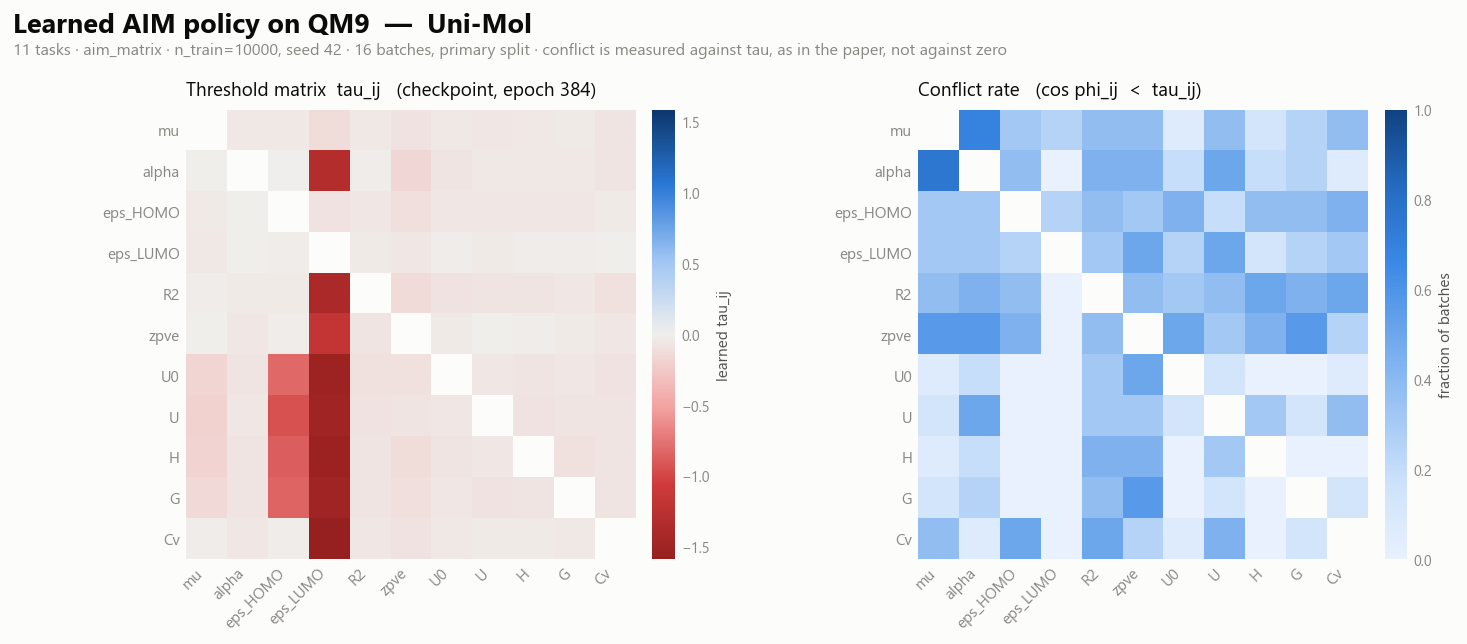

In [3]:
def tau_at(epoch):
    i = int(np.argmin(np.abs(trace["epoch"] - epoch)))
    t = trace["tau"][i]
    return (np.asarray(t, dtype=float) if np.ndim(t) else
            np.full((len(tasks), len(tasks)), float(t))), int(trace["epoch"][i])

rows = [("checkpoint", ck_epoch, tau_ck, conflict_rate)]
for e in (EPOCHS or []):
    t, real = tau_at(e)
    rows.append((f"epoch {real}", real, t, None))    # cos not measured there

tmax = max(abs(r[2][off]).max() for r in rows) or 0.05
H = 4.9 * len(rows)                      # header offsets in inches, so they
Y_TITLE, Y_SUB = 1 - 0.30 / H, 1 - 0.62 / H      # hold at any row count
fig, axes = plt.subplots(len(rows), 2, figsize=(11.2, H), squeeze=False)

for r, (label, ep, tau, rate) in enumerate(rows):
    im0 = C.heatmap(axes[r][0], tau, tasks, C.cmap("diverging"), -tmax, tmax,
                    f"Threshold matrix  tau_ij   ({label}, epoch {ep})",
                    "{:+.2f}", ANNOTATE)
    cb = fig.colorbar(im0, ax=axes[r][0], fraction=.046, pad=.03)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=C.MUTED, labelsize=8)
    cb.set_label("learned tau_ij", color=C.SECONDARY, fontsize=8.5)

    if rate is None:
        axes[r][1].set_axis_off()
        axes[r][1].text(.5, .5, "conflict rate not measured here",
                        ha="center", va="center", fontsize=9, color=C.MUTED)
        continue
    im1 = C.heatmap(axes[r][1], rate, tasks, C.cmap("sequential"), 0, 1,
                    "Conflict rate   (cos phi_ij  <  tau_ij)",
                    "{:.2f}", ANNOTATE)
    cb = fig.colorbar(im1, ax=axes[r][1], fraction=.046, pad=.03)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=C.MUTED, labelsize=8)
    cb.set_label("fraction of batches", color=C.SECONDARY, fontsize=8.5)

fig.suptitle(f"Learned AIM policy on QM9  —  {BACKBONE}", x=.01, y=Y_TITLE,
             ha="left", fontsize=15, fontweight="bold", color=C.INK)
fig.text(.01, Y_SUB,
         f"{len(tasks)} tasks · {METHOD} · n_train={C.N_TRAIN}, seed {C.SEED} · "
         f"{cos.shape[0]} batches, primary split · "
         "conflict is measured against tau, as in the paper, not against zero",
         fontsize=9, color=C.MUTED, ha="left")
fig.subplots_adjust(left=.08, right=.97, top=1 - 1.05 / H,
                    bottom=.08, hspace=.35, wspace=.30)
C.save(fig, f"policy_diagnostics_{BACKBONE.replace('-','')}_{TAG}", TAG)
plt.show()

## Why one row and not two

The paper shows Epoch 10 on top and Epoch 100 below. Reproducing that needs the
cosine matrix *at those epochs*, and two things block it:

1. `train.py` never logged `cos(g_i, g_j)` — it is computed inside `_step_aim`
   and discarded.
2. `best_model.pt` is overwritten on every improvement, so there is no
   epoch-10 or epoch-100 model state left to measure.

Both are fixed for future runs: `GNN/src/train.py` now takes `--log_cosine`
(writes `cos_mean` and `cos_conflict_freq` per epoch) and `--keep_every N`
(snapshots `epoch_NNNN.pt`). Re-run with those and this notebook can grow the
extra rows.

Meanwhile `EPOCHS = [10, 100]` still gives you the **τ** column at those epochs —
that half is free.

saved E:\Projects\aim_mtl\notebooks\figures\11task\tau_trace_UniMol_11task.png


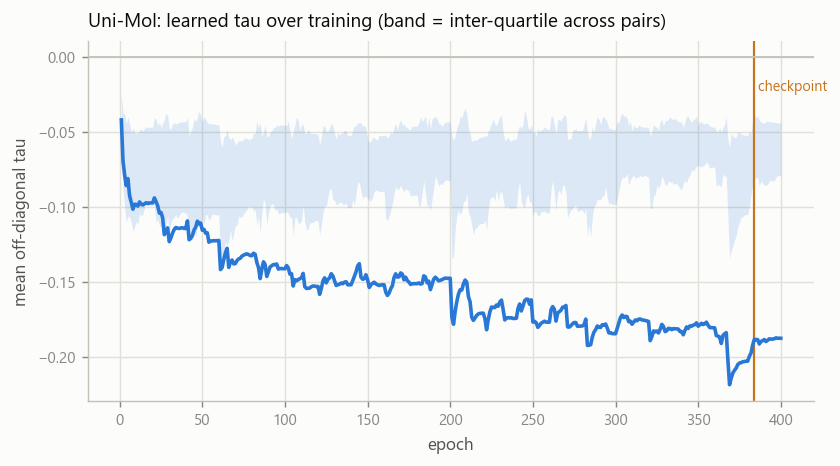

In [4]:
# tau alone, across training -- no measurement needed
fig, ax = plt.subplots(figsize=(7.2, 3.6))
tau_all = trace["tau"]
if tau_all.ndim == 3:
    v = tau_all[:, off]
    ax.plot(trace["epoch"], v.mean(1), color=C.BACKBONE_COLOUR[BACKBONE], lw=2, zorder=3)
    ax.fill_between(trace["epoch"], np.percentile(v, 25, axis=1),
                    np.percentile(v, 75, axis=1),
                    color=C.BACKBONE_COLOUR[BACKBONE], alpha=.15, lw=0)
else:
    ax.plot(trace["epoch"], tau_all, color=C.BACKBONE_COLOUR[BACKBONE], lw=2)
ax.axvline(ck_epoch, color=C.ACCENT, lw=1.2)
ax.text(ck_epoch, ax.get_ylim()[1], " checkpoint", color=C.ACCENT, fontsize=8,
        va="top", ha="left")
ax.axhline(0, color=C.AXIS, lw=1)
ax.set_xlabel("epoch"); ax.set_ylabel("mean off-diagonal tau")
ax.set_title(f"{BACKBONE}: learned tau over training (band = inter-quartile across pairs)",
             color=C.INK, loc="left", pad=8)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(True, zorder=0); ax.set_axisbelow(True)
C.save(fig, f"tau_trace_{BACKBONE.replace('-','')}_{TAG}", TAG); plt.show()